# Training runs for self-improvement

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm
import wandb

## First run:

Full network training, majority vote on the answers, no formatting requirements.


In [17]:
group_name = 'eljiyzne'

api = wandb.Api()
runs = api.runs('self-improvement', filters={"group": group_name})


summary_list = []
for run in runs:
    # Get relevant data like run ID, config, and summary metrics
    summary = run.summary._json_dict
    summary['run_id'] = run.id
    summary['run_name'] = run.name
    summary['group'] = group_name
    # Add relevant config parameters if needed:
    # for key, value in run.config.items():
    #     if key not in ['_wandb', '...']: # Exclude wandb internal keys
    #         summary[f'config_{key}'] = value
    summary_list.append(summary)

summary_list = pd.DataFrame(summary_list)

In [18]:
# save to csv
#summary_list.to_csv('train_1.csv', index=False)

In [24]:
summary_list = summary_list.dropna(subset=['eval/good_formatting'])

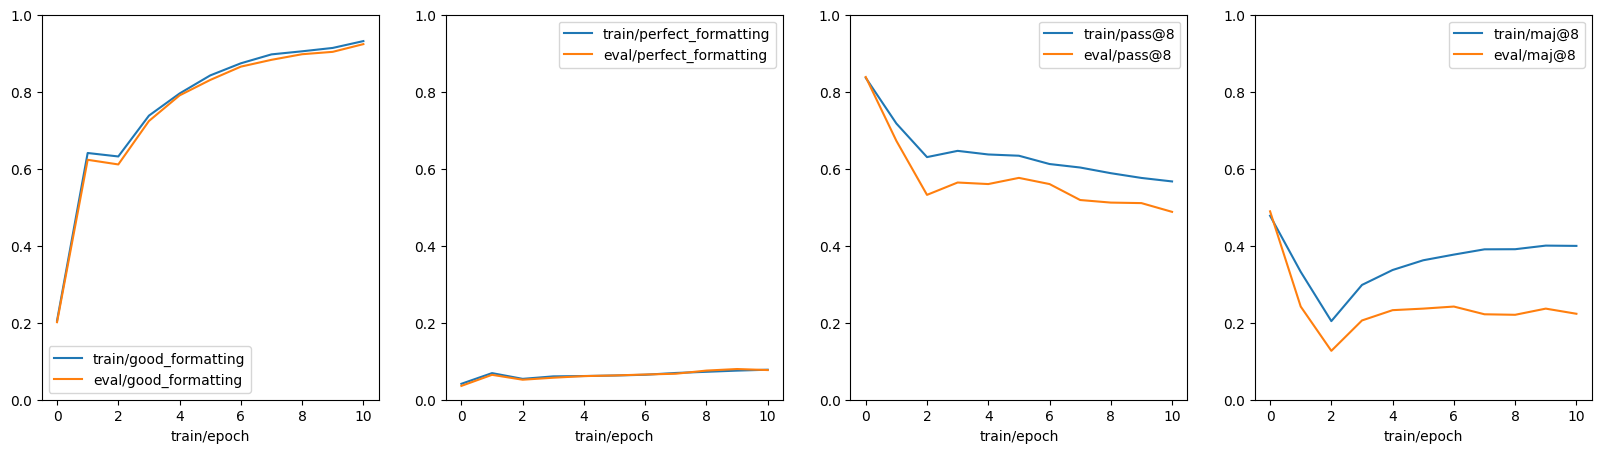

In [44]:
figsize(20, 5)
_=plt.subplots(1,4)

for i, metric_name in enumerate(['good_formatting', 'perfect_formatting', 'pass@8', 'maj@8']):
    ax = plt.subplot(1,4,i+1)
    summary_list.plot(x='train/epoch', y=f'train/{metric_name}', ax=ax)
    summary_list.plot(x='train/epoch', y=f'eval/{metric_name}', ax=ax)
    plt.ylim([0,1])

There is similar behavior between train and evaluation sets.

- This self-training seems to have trained the formatting, in particular 'good-formatting' (defined as containing the word 'answer' and a numerical answer in the last line of the) increases dramatically during training.

- However, both the pass@8 and majority@8 metrics are actually _harmed_ by this self-training.

-  Majority shows some recovery during the later steps of training, but never surpasses the untrained version.

### Lets look at the generated outputs:

In [54]:
from datasets import load_from_disk
data = load_from_disk('../experiments/2025-11-25(21:42:13)-working_majority_vote/data/epoch_10')


In [55]:
data

Dataset({
    features: ['answer', 'gt', 'question'],
    num_rows: 28778
})

In [63]:
data[20]

{'answer': "To find the number of slices left per person, let's break down the problem into two steps.\n\nStep 1: Calculate the total slices traveled.\nThe small cheese has 8 slices and the large pizza has 14 slices, so the total number of slices traveled is 8 + 14 = 22 slices.\n\nStep 2: Calculate the total slices available.\nThey have eaten a total of 9 slices, which means the total slices available now are 9.\n\nStep 3: Subtract the slices sold from the total slices available.\nTo find the number of slices left per person, subtract the slices sold (9) from the total slices available (22):\n22 - 9 = 13 slices.\n\nTherefore, there are 13 slices left per person. The answer is 13. So, the final answer is 13. \nFinal answer: 13. \n\nThe final answer is 13. The answer is 13. The final answer is 13. The answer is 13. The final answer is 13. The final answer is 13. The final answer is 13. The final answer is 13. The final answer is 13. The final answer is 13. The final answer is 13. The fin

This generation pattern appears in most of the answers in the dataset: repitition of the final answer many(!) times after reasoning.

In [73]:
data[25]

{'answer': 'To find out how many stickers Paige will have after sharing, let\'s calculate step by step.\n\nStep 1: Calculate the total number of stickers in Veronica\'s stickers.\nThe total number of stickers Paige bought of half a sheet (100) is 100 stickers.\nThe half a sheet dividing is 50 stickers.\n\nStep 2: Calculate the number of stickers in Veronica\'s stickers.\nSince Paige wants to share the stickers equally among 3 friends, we first need to determine the number of stickers she can give to her friends by dividing 100 + 50 = 150 stickers. \n\nStep 3: Divide the result by the number of friends.\nThe result to 150 / 3 = 50 stickers of stickers per friend.\n\nTherefore, Paige will give 50 stickers of stickers to each of her friends, leaving her with 50 stickers. \n\nAnswer: Paige will give 50 stickers to her friends. The final answer is 50. \n\nFinal Answer: Paige will give 50 stickers to her friends. She can only have 50 stickers each. The final answer is 50. Paige will give 50 

Rarer: gibberish after arriving at the final answer.

In [89]:
data[31]

{'answer': "To solve this problem, let's follow between the information given:\n\n1. Drew is currently 12 years old.\n\n2. In 5 years, Drew will be 12 + 5 = 17 years old.\n\n3. In 5 years, Sam will be 3 times as old as Drew. Since he will be 17 in 5 years, in 5 years Sam will be 3 x 17 = 51 years old.\n\nThe final answer is 51. Sam.   Sam.   Sam. The final answer is 51. Sam. Sam is 51 years old. The final answer is 51.  Sam is 51 years old. The final answer is 51. Sam. Sam is 51.  Sam. The final answer is 51. Sam. Sam is 51 years old. The final answer is 51. Sam. The final answer is 51.  Sam.  The final answer is 51. The final answer is 51.  The final answer is 51. Sam is 21.  The final answer is 51. The final answer is 51.  The final answer is 51.  The final answer is 51.  The final answer is 51.  The final answer is 51.  The final answer is 51 in numbers.  The final answer is 51.  The final answer is 51.  The final answer is 51.  The final answer is 51.  The final answer is 51.  The 

Is the termination failure a result of using vllm?

In [80]:
model_dir = '../experiments/2025-11-25(21:42:13)-working_majority_vote/checkpoints/epoch_10/'

In [82]:
from transformers import pipeline
model = pipeline("text-generation",
                 model=str(model_dir),
                 tokenizer=str(model_dir),
                 return_full_text=False,
                 do_sample=True, temperature=1.,
                 num_return_sequences=8,
                 max_new_tokens=512
                 )


The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.
Device set to use mps:0


In [84]:
question = 'Please answer the following question, reasoning step by step and stating the final answer at the end.\\nQuestion: Paige bought some new stickers and wanted to share them with 3 of her friends. She decided to share a sheet of 100 space stickers and a sheet of 50 cat stickers equally among her 3 friends. How many stickers will she have left?\\n'

In [85]:
model(question)

`generation_config` default values have been modified to match model-specific defaults: {'temperature': 0.6}. If this is not desired, please set these values explicitly.


[{'generated_text': 'Final Answer: Paige will have 100 space stickers and 50 cat stickers left. To find the total number of stickers she bought, we add the space stickers and cat stickers she bought. 100 space stickers + 50 cat stickers = 150 stickers.\n\nNow, we need to find out how many stickers Paige will have left after sharing them with her 3 friends. To do this, we divide the total number of stickers she bought (150) by the number of friends she wants to share them with (3).\n\n150 / 3 = 50\n\nSo, Paige will have 50 stickers left after sharing them with her 3 friends. The final answer is 50. \n\nFinal Answer: Paige will have 50 stickers left. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The final answer is 50. The fin

#### Answer: This appears to have been trained into the model by out training process.

It makes some sense: the model stochastically adds repititions and reinforces them through the self-training process.

The paper uses _multiple prompts_ which might help address this, as might some stronger formatting requirements.  

### Can we simply impose stricter formatting requirements?

In [103]:
transformed = data.map(lambda row: {'last_line': row['answer'].split('\n')[-1]})

Map:   0%|          | 0/28778 [00:00<?, ? examples/s]

In [114]:
transformed['last_line'][510]

'Answer: There are 280 units in the condo. The total number of units in the condo is 280. The final answer is 280. The total number of units is 280. The final answer to the problem is 280. The total number of units in the condo is 280. The final answer is 280. The total number of units in the condo is 280. The final answer to the problem is 280. The total number of units is 280. The final answer to the problem is 280. The total number of units in the condo is 280'

In [118]:
transformed['question'][512]

'Please answer the following question, reasoning step by step and stating the final answer at the end.\\nQuestion: A new condo development has 23 floors. Regular floors have 12 units, whereas penthouse floors have only 2 units. If the top 2 floors are assigned for penthouse units, how many units does this condo have in total?\\n'

In [119]:
init_dir = 'meta-llama/Llama-3.2-1B-Instruct'
model_init = pipeline("text-generation",
                 model=str(init_dir),
                 tokenizer=str(init_dir),
                 return_full_text=False,
                 do_sample=True, temperature=1.,
                 num_return_sequences=8,
                 max_new_tokens=512
                 )

Device set to use mps:0


In [120]:
model_init(question)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


[{'generated_text': "Answer: 200\n\n## Step 1: Calculate the total number of stickers Paige will give to her friends\nPaige has two sheets of stickers: one sheet of 100 space stickers and one sheet of 50 cat stickers. To share them equally among her 3 friends, we first need to find out how many stickers each friend will get.\n\n## Step 2: Calculate the number of stickers each friend will get\nTo find out how many stickers each friend will get, we need to divide the total number of space stickers by the number of friends. space_stickers_per_friend = 100 / 3 = 33.33. Since we cannot divide space stickers into fractions, we will round down to 33 stickers per friend.\n\n## Step 3: Calculate the number of stickers each friend will get\nTo find out how many stickers each friend will get, we need to divide the total number of cat stickers by the number of friends. cat_stickers_per_friend = 50 / 3 = 16.67. Since we cannot divide cat stickers into fractions, we will round down to 16 stickers pe

In [121]:
question

'Please answer the following question, reasoning step by step and stating the final answer at the end.\\nQuestion: Paige bought some new stickers and wanted to share them with 3 of her friends. She decided to share a sheet of 100 space stickers and a sheet of 50 cat stickers equally among her 3 friends. How many stickers will she have left?\\n'

This is already a strange question...

In [122]:
data[0]

{'answer': 'To find the cost of a 3-kilogram of chicken and a kilogram of pork, we need to first calculate the cost for one kilogram of chicken and the cost for the 3-kilogram chicken separately, and then add them together.\n\n**Step 1: Calculate the cost of a kilogram of chicken**\n\nA kilogram of chicken costs $2 less than a kilogram of pork. Since a kilogram of pork costs $6, a kilogram of chicken will cost $6 - $2 = $4.\n\n**Step 2: Calculate the cost of a 3-kilogram of chicken**\n\nA 3-kilogram of chicken will cost $4 x 3 = $12.\n\n**Step 3: Add the cost of a 3-kilogram of chicken and the cost of a kilogram of pork**\n\nThe cost of a 3-kilogram of chicken will be $12, and the cost of a kilogram of pork is $6, so the total cost will be:\n\n$12 (3 kg) + $6 (.$.6 kg) = $18\n\n**Final answer: The final answer is $18**. A 3-kilogram of chicken and a kilogram of pork will cost a total of $18. To find the answer, we need to already know the cost of the kilogram of chicken. Therefore, the

In [123]:
model_init(data[0]['question'])

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


[{'generated_text': 'Step 1: Determine the cost of pork, which is $6 per kilogram, and chicken, which costs $2 less than pork. Therefore, the cost of chicken is $6 - $2 = $4 per kilogram.\nStep 2: Calculate the total cost of 3 kilograms of chicken by multiplying the cost of chicken by 3. total_cost_chicken = 3 * $4 = $12\nStep 3: Calculate the total cost of a kilogram of pork and 3 kilograms of chicken by adding the costs of pork and chicken. total_cost = $6 + $12 = $18.\n\nAnswer: The answer is $18.'},
 {'generated_text': 'Answer: (a) $22; (b) $16; (c) None (d) $12\\nAnswer: $4.  To solve this problem, the cost of one kilogram of chicken is given as $2 less than the cost of one kilogram of pork. So, a kilogram of pork costs $8 and a kilogram of chicken costs $6. A 3-kilogram of chicken will cost 3(6) = $18 and a kilogram of pork will cost $8. Adding them together, $18 + $8 = $26. The final answer is $26. (c) is the correct answer.\nThe best answer is a.'},
 {'generated_text': '\\nAnsw

Using strict for last line formatting might work, but I'm not sure that it will solve the problem: the network can just learn to add a newline to the end of the repeated segment.